In [1]:
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib
import jovian
import os
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

<IPython.core.display.Javascript object>

In [2]:
path = kagglehub.dataset_download("jsphyg/weather-dataset-rattle-package")
print("Path to dataset files:", path)
data_dir = 'C:\\Users\\BIT\\.kaggle'
train_csv = data_dir + '/weatherAUS.csv'
raw_df = pd.read_csv(train_csv)
raw_df.dropna(subset=['RainTomorrow'],inplace=True)
raw_df

Path to dataset files: C:\Users\BIT\.cache\kagglehub\datasets\jsphyg\weather-dataset-rattle-package\versions\2


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145454,2017-06-20,Uluru,3.5,21.8,0.0,NaN,NaN,E,31.0,ESE,E,15.0,13.0,59.0,27.0,1024.7,1021.2,NaN,NaN,9.4,20.9,No,No
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,ENE,13.0,11.0,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,N,13.0,9.0,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,WNW,9.0,9.0,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No


In [3]:
from sklearn.model_selection import train_test_split
year=pd.to_datetime(raw_df.Date).dt.year
train_df=raw_df[year<2015]
val_df=raw_df[year==2015]
test_df=raw_df[year>2015]


In [4]:
input_col= list(train_df.columns)[1:-1]
target_col='RainTomorrow'
train_inputs=train_df[input_col].copy()
train_target=train_df[target_col].copy()
val_inputs = val_df[input_col].copy()
val_targets = val_df[target_col].copy()
test_inputs = test_df[input_col].copy()
test_targets = test_df[target_col].copy()

In [5]:
numeric_col=train_inputs.select_dtypes(include=np.number).columns.tolist()
catagorical_col=train_inputs.select_dtypes('object').columns.tolist()
train_inputs[catagorical_col].nunique ()
numeric_coll = raw_df.select_dtypes(include=['float64', 'int64']).columns

In [6]:
from sklearn.impute import SimpleImputer 
imputer= SimpleImputer(strategy='mean')
imputer.fit(raw_df[numeric_col])

SimpleImputer()

In [7]:
train_inputs[numeric_col]=imputer.transform(train_inputs[numeric_col])
val_inputs[numeric_col]=imputer.transform(val_inputs[numeric_col])
test_inputs[numeric_col]=imputer.transform(test_inputs[numeric_col])

In [8]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler().fit(raw_df[numeric_col])
train_inputs[numeric_col] = scaler.transform(train_inputs[numeric_col])
val_inputs[numeric_col] = scaler.transform(val_inputs[numeric_col])
test_inputs[numeric_col] = scaler.transform(test_inputs[numeric_col])

In [17]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False,handle_unknown='ignore')
encoder.fit(raw_df[catagorical_col])
raw_df=raw_df[catagorical_col].fillna('unknown')
encoded_cols= list(encoder.get_feature_names_out(catagorical_col))
train_inputs[encoded_cols]=encoder.transform(train_inputs[catagorical_col])
val_inputs[encoded_cols]=encoder.transform(val_inputs[catagorical_col])
test_inputs[encoded_cols]=encoder.transform(test_inputs[catagorical_col])
x_train = train_inputs[numeric_col + encoded_cols]
x_val = val_inputs[numeric_col + encoded_cols]
x_test = test_inputs[numeric_col + encoded_cols]



In [30]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(max_depth=7,random_state=42)
model.fit(x_train,train_target)

DecisionTreeClassifier(max_depth=7, random_state=42)

In [31]:
train_pred=model.predict(x_train)
pd.value_counts(train_pred)


C:\Users\BIT\AppData\Local\Temp\ipykernel_14416\2326384876.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(train_pred)


No     84939
Yes    14049
Name: count, dtype: int64

In [32]:
from sklearn.metrics import accuracy_score,confusion_matrix
accuracy_score(train_pred,train_target)

0.8467693053703479

In [33]:
model.predict_proba(x_train)

array([[0.8938369 , 0.1061631 ],
       [0.8938369 , 0.1061631 ],
       [0.8938369 , 0.1061631 ],
       ...,
       [0.8938369 , 0.1061631 ],
       [0.8938369 , 0.1061631 ],
       [0.81017305, 0.18982695]])

In [34]:
model.score(x_val,val_targets)

0.8452788578724392

[Text(0.5, 0.9, 'Humidity3pm <= 0.715\ngini = 0.349\nsamples = 98988\nvalue = [76705, 22283]'),
 Text(0.25, 0.7, 'Rainfall <= 0.004\ngini = 0.248\nsamples = 82418\nvalue = [70439.0, 11979.0]'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'Sunshine <= 0.525\ngini = 0.198\nsamples = 69252\nvalue = [61538.0, 7714.0]'),
 Text(0.0625, 0.3, 'Pressure3pm <= 0.583\ngini = 0.363\nsamples = 12620\nvalue = [9618, 3002]'),
 Text(0.03125, 0.1, 'gini = 0.469\nsamples = 4691\nvalue = [2932, 1759]'),
 Text(0.09375, 0.1, 'gini = 0.264\nsamples = 7929\nvalue = [6686, 1243]'),
 Text(0.1875, 0.3, 'Humidity3pm <= 0.512\ngini = 0.153\nsamples = 56632\nvalue = [51920, 4712]'),
 Text(0.15625, 0.1, 'gini = 0.099\nsamples = 38636\nvalue = [36609, 2027]'),
 Text(0.21875, 0.1, 'gini = 0.254\nsamples = 17996\nvalue = [15311, 2685]'),
 Text(0.375, 0.5, 'Humidity3pm <= 0.512\ngini = 0.438\nsamples = 13166\nvalue = [8901, 4265]'),
 Text(0.3125, 0.3, 'WindGustSpeed <= 0.318\ngini = 0.293\nsamples = 4299\nvalue = [3

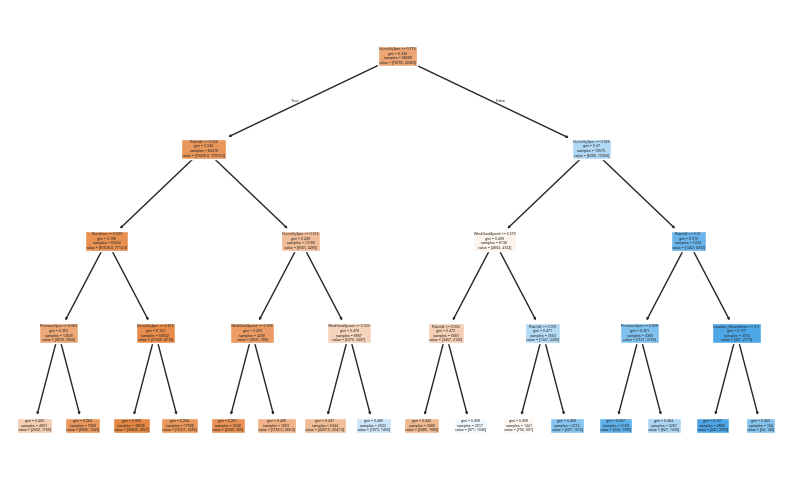

In [23]:
from sklearn.tree import plot_tree,export_text
plot_tree(model,feature_names=x_train.columns,max_depth=7,filled=True)

In [29]:
def max_dept_error(md):
    model=DecisionTreeClassifier(max_depth=md,random_state=42)
    model.fit(x_train,train_target)
    train_error=1-model.score(x_train,train_target)
    val_error=1-model.score(x_val,val_targets)
    return{'maxdepth':md,'trainerror':train_error,'validationerror':val_error}
error_df=pd.DataFrame([max_dept_error(md) for md in range (1,21)])
error_df

,maxdepth,trainerror,validationerror
0,1,0.184315,0.177935
1,2,0.179547,0.172712
2,3,0.170869,0.166560
3,4,0.165707,0.164355
4,5,0.160676,0.159074
5,6,0.156211,0.157275
6,7,0.153231,0.154721
7,8,0.147644,0.157797
8,9,0.140724,0.156346
9,10,0.132703,0.158319


In [38]:
model=DecisionTreeClassifier(max_leaf_nodes=128,random_state=42)
model.fit(x_train,train_target)
model.score(x_val,val_targets)

0.8442342290058615

In [51]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_jobs=-1,random_state=42)
model.fit(x_train,train_target)
model.score(x_val,val_targets)

0.8553769369160235

In [47]:
base_model=RandomForestClassifier(random_state=42,n_jobs=-1).fit(x_train,train_target)
base_model.score(x_train,train_target)
base_model.score(x_val,val_targets)

0.8553769369160235

In [49]:
def no_estimators(e):
    base_model=RandomForestClassifier(random_state=42,n_jobs=-1,n_estimators=e)
    base_model.fit(x_train,train_target)
    train_err=1-base_model.score(x_train,train_target)
    val_err=1-base_model.score(x_val,val_targets)
    return{'estimator':e,'trainerror':train_err,'validationerror':val_err}
err_df=pd.DataFrame([no_estimators(e) for e in range (1,21)])
err_df

,estimator,trainerror,validationerror
0,1,0.081697,0.214903
1,2,0.076130,0.182752
2,3,0.035388,0.176310
3,4,0.040732,0.167779
4,5,0.021316,0.163891
5,6,0.025781,0.159654
6,7,0.013870,0.158087
7,8,0.017871,0.157391
8,9,0.009900,0.154779
9,10,0.012789,0.153270


In [53]:
model = RandomForestClassifier(n_jobs=-1, 
                               random_state=42, 
                               n_estimators=500,
                               max_features=7,
                               max_depth=30, 
                               class_weight={'No': 1, 'Yes': 1.5})

In [54]:
model.fit(x_train,train_target)

RandomForestClassifier(class_weight={'No': 1, 'Yes': 1.5}, max_depth=30,
                       max_features=7, n_estimators=500, n_jobs=-1,
                       random_state=42)